---
# Case1 SC — Split별 Train/Val 시각화
- **모델 구분**: 색상 (LSTM=파랑, Scratch=빨강, Finetune=초록, Freeze=주황)
- **Train/Val 구분**: 선종류 (Train=실선 `-`, Val=점선 `--`)
- val NMSE 최저점에 ★ 마커 표시

In [8]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# ── 설정 ───────────────────────────────────────────────────────────
LOG_DIR = Path('.')

SPLIT_META = {
    'split1': {'scenes': 1000, 'batch': 256, 'n_sc':  64},
    'split2': {'scenes': 1000, 'batch': 256, 'n_sc':  64},
    'split3': {'scenes': 1000, 'batch':  64, 'n_sc':  64},
    'split4': {'scenes': 7000, 'batch': 256, 'n_sc':  64},
    'split5': {'scenes': 1000, 'batch': 256, 'n_sc': 512},
}

MODEL_NAMES   = ['LSTM', 'lwm_fromScratch', 'lwm_finetune', 'lwm_freeze']
MODEL_DISPLAY = ['LSTM', 'Scratch',          'Finetune',     'Freeze']
MODEL_COLORS  = {
    'LSTM':            '#2196F3',
    'lwm_fromScratch': '#F44336',
    'lwm_finetune':    '#4CAF50',
    'lwm_freeze':      '#FF9800',
}
MODEL_FILE = {
    'LSTM':            'lstm',
    'lwm_fromScratch': 'lwm_fromScratch',
    'lwm_finetune':    'lwm_finetune',
    'lwm_freeze':      'lwm_freeze',
}

EPOCH_RE = re.compile(
    r'\[(\d+)/\d+\].*?'
    r'train loss=([\d.]+) nmse=([-\d.]+)dB.*?'
    r'val loss=([\d.]+) nmse=([-\d.]+)dB'
)
BEST_RE = re.compile(r'best@(\d+): val nmse=([-\d.]+)dB')

def parse_log(path):
    epochs, tr_loss, va_loss, tr_nmse, va_nmse = [], [], [], [], []
    best_epoch, best_nmse = None, None
    with open(path, encoding='utf-8') as f:
        for line in f:
            m = EPOCH_RE.search(line)
            if m:
                epochs.append(int(m.group(1)))
                tr_loss.append(float(m.group(2)))
                tr_nmse.append(float(m.group(3)))
                va_loss.append(float(m.group(4)))
                va_nmse.append(float(m.group(5)))
                continue
            m = BEST_RE.search(line)
            if m:
                best_epoch = int(m.group(1))
                best_nmse  = float(m.group(2))
    return {
        'epochs':     np.array(epochs),
        'tr_loss':    np.array(tr_loss),
        'va_loss':    np.array(va_loss),
        'tr_nmse':    np.array(tr_nmse),
        'va_nmse':    np.array(va_nmse),
        'best_epoch': best_epoch,
        'best_nmse':  best_nmse,
    }

def get_log_path(sp, mk):
    N  = SPLIT_META[sp]['scenes']
    mf = MODEL_FILE[mk]
    return LOG_DIR / f'case1_{sp}_{mf}_scene{N}.txt'

# 전체 로드
data = {}
for sp in SPLIT_META:
    data[sp] = {}
    for mk in MODEL_NAMES:
        path = get_log_path(sp, mk)
        if path.exists():
            data[sp][mk] = parse_log(path)
            d = data[sp][mk]
            best_s = f"{d['best_nmse']:.4f} dB" if d['best_nmse'] is not None else 'N/A'
            print(f'  [✓] {sp} / {mk:20s}  best={best_s}  (ep {d["best_epoch"]})')
        else:
            print(f'  [✗] {sp} / {mk:20s}  파일 없음: {path.name}')

  [✓] split1 / LSTM                  best=-12.0045 dB  (ep 3)
  [✓] split1 / lwm_fromScratch       best=-11.9905 dB  (ep 10)
  [✗] split1 / lwm_finetune          파일 없음: case1_split1_lwm_finetune_scene1000.txt
  [✗] split1 / lwm_freeze            파일 없음: case1_split1_lwm_freeze_scene1000.txt
  [✓] split2 / LSTM                  best=-12.0077 dB  (ep 9)
  [✓] split2 / lwm_fromScratch       best=-12.0068 dB  (ep 7)
  [✓] split2 / lwm_finetune          best=-12.0314 dB  (ep 15)
  [✓] split2 / lwm_freeze            best=-12.0028 dB  (ep 45)
  [✓] split3 / LSTM                  best=-11.9985 dB  (ep 1)
  [✓] split3 / lwm_fromScratch       best=-12.0015 dB  (ep 6)
  [✓] split3 / lwm_finetune          best=-11.9695 dB  (ep 2)
  [✓] split3 / lwm_freeze            best=-12.0051 dB  (ep 27)
  [✓] split4 / LSTM                  best=-12.1641 dB  (ep 1)
  [✓] split4 / lwm_fromScratch       best=-12.1620 dB  (ep 2)
  [✓] split4 / lwm_finetune          best=-12.1622 dB  (ep 2)
  [✓] split4 / lwm_freez

In [9]:
def _add_legends(ax, present_models):
    model_handles = [
        mlines.Line2D([], [], color=MODEL_COLORS[mk], lw=2, label=md)
        for mk, md in zip(MODEL_NAMES, MODEL_DISPLAY) if mk in present_models
    ]
    tv_handles = [
        mlines.Line2D([], [], color='gray', ls='-',  lw=2, label='Train'),
        mlines.Line2D([], [], color='gray', ls='--', lw=2, label='Val'),
    ]
    leg1 = ax.legend(handles=model_handles, title='Model', fontsize=9, loc='upper right')
    ax.add_artist(leg1)
    ax.legend(handles=tv_handles, title='Phase', fontsize=9, loc='upper center')

def plot_split(sp):
    sp_data = data.get(sp, {})
    if not sp_data:
        print(f'{sp}: 데이터 없음'); return

    m   = SPLIT_META[sp]
    ttl = f"{sp}  (scenes={m['scenes']}, batch={m['batch']}, N_SC={m['n_sc']})"

    fig, (ax_l, ax_n) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(ttl, fontsize=13, fontweight='bold')

    for mk, md in zip(MODEL_NAMES, MODEL_DISPLAY):
        if mk not in sp_data:
            continue
        d   = sp_data[mk]
        col = MODEL_COLORS[mk]

        # Loss
        ax_l.plot(d['epochs'], d['tr_loss'], color=col, ls='-',  lw=1.8, alpha=0.85)
        ax_l.plot(d['epochs'], d['va_loss'], color=col, ls='--', lw=1.8, alpha=0.85)

        # NMSE
        ax_n.plot(d['epochs'], d['tr_nmse'], color=col, ls='-',  lw=1.8, alpha=0.85)
        ax_n.plot(d['epochs'], d['va_nmse'], color=col, ls='--', lw=1.8, alpha=0.85)

        if d['best_epoch']:
            be = d['best_epoch'] - 1
            if be < len(d['va_nmse']):
                ax_n.scatter(d['epochs'][be], d['va_nmse'][be],
                             color=col, s=90, zorder=5,
                             marker='*', edgecolors='black', linewidths=0.5)

    for ax, ylabel, sub_ttl in [
        (ax_l, 'Loss (MSE)', 'Loss'),
        (ax_n, 'NMSE (dB)',  'NMSE'),
    ]:
        ax.set_title(sub_ttl, fontsize=11)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        _add_legends(ax, sp_data)

    fig.tight_layout()
    plt.show()

## split1  (scenes=1000, batch=256, N_SC=64)  —  time-based 75/25 split

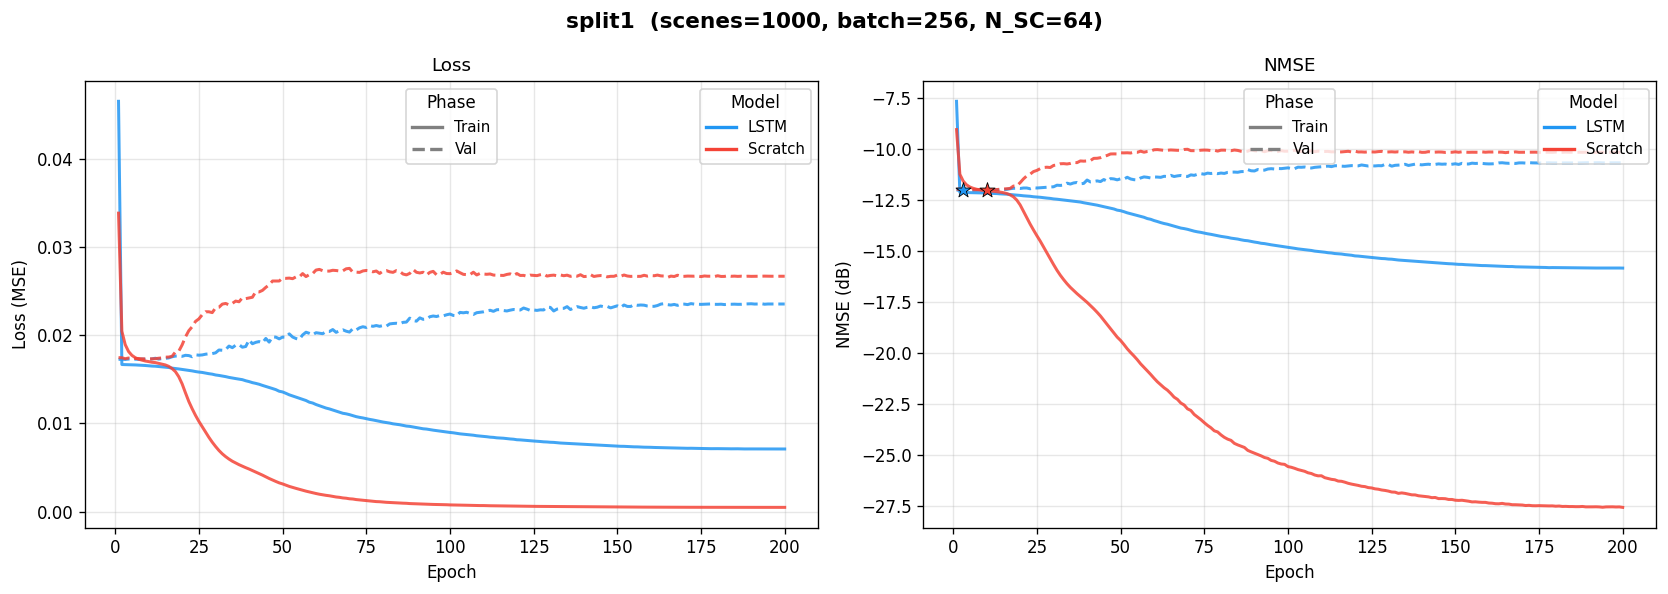

In [10]:
plot_split('split1')

## split2  (scenes=1000, batch=256, N_SC=64)  —  baseline

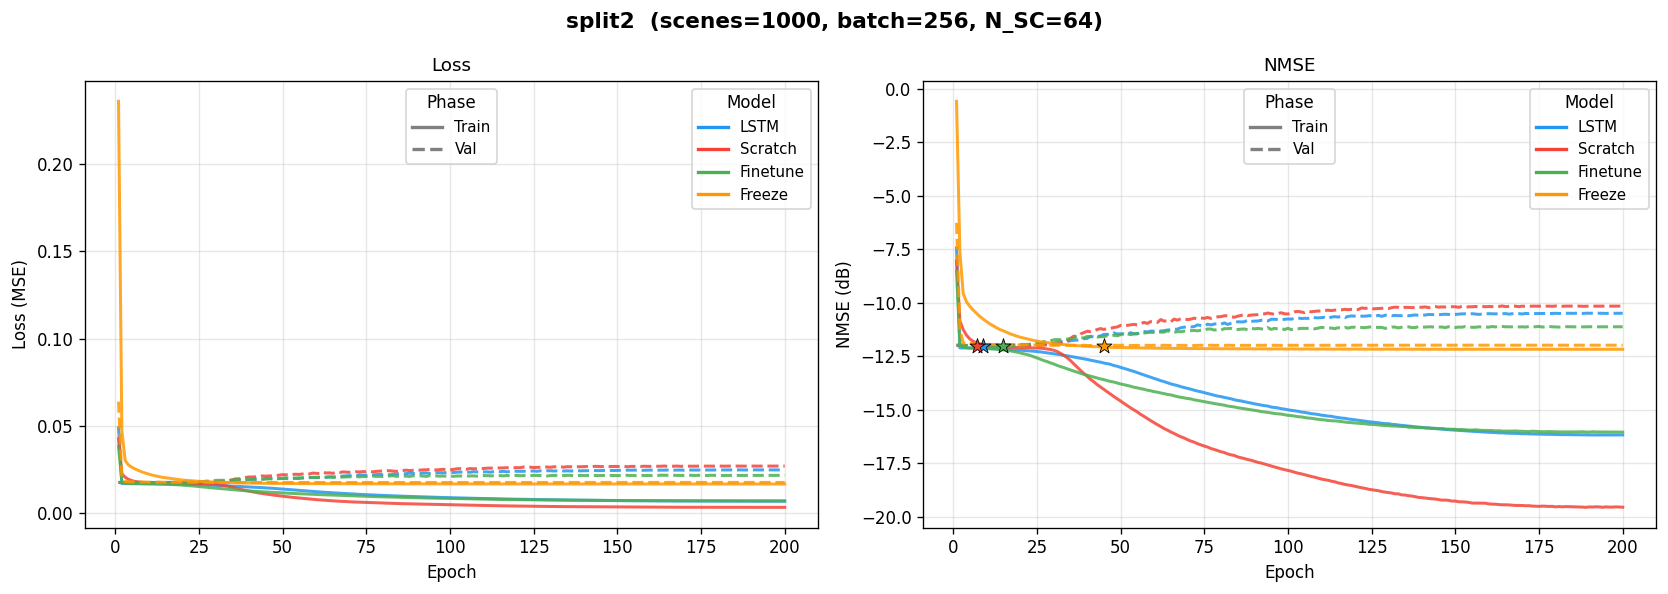

In [11]:
plot_split('split2')

## split3  (scenes=1000, batch=64, N_SC=64)

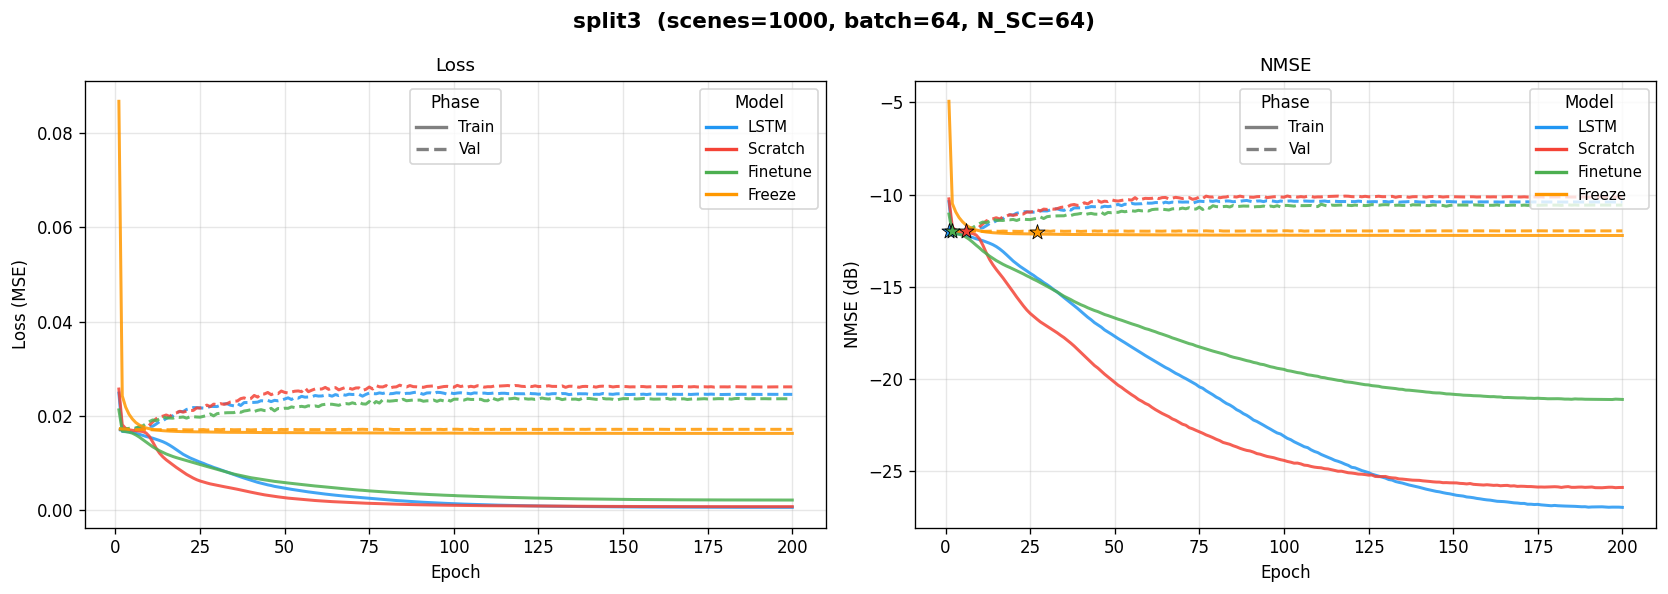

In [12]:
plot_split('split3')

## split4  (scenes=7000, batch=256, N_SC=64)

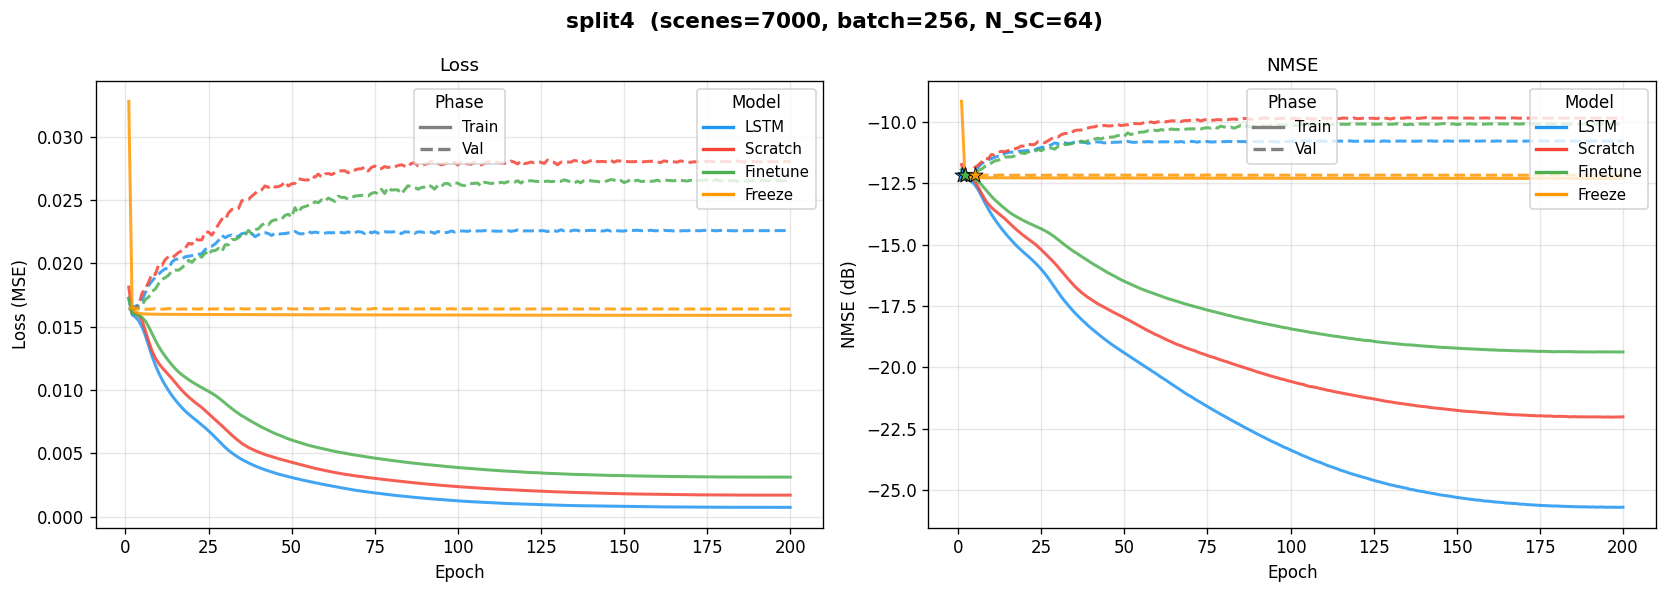

In [13]:
plot_split('split4')

## split5  (scenes=1000, batch=256, N_SC=512)

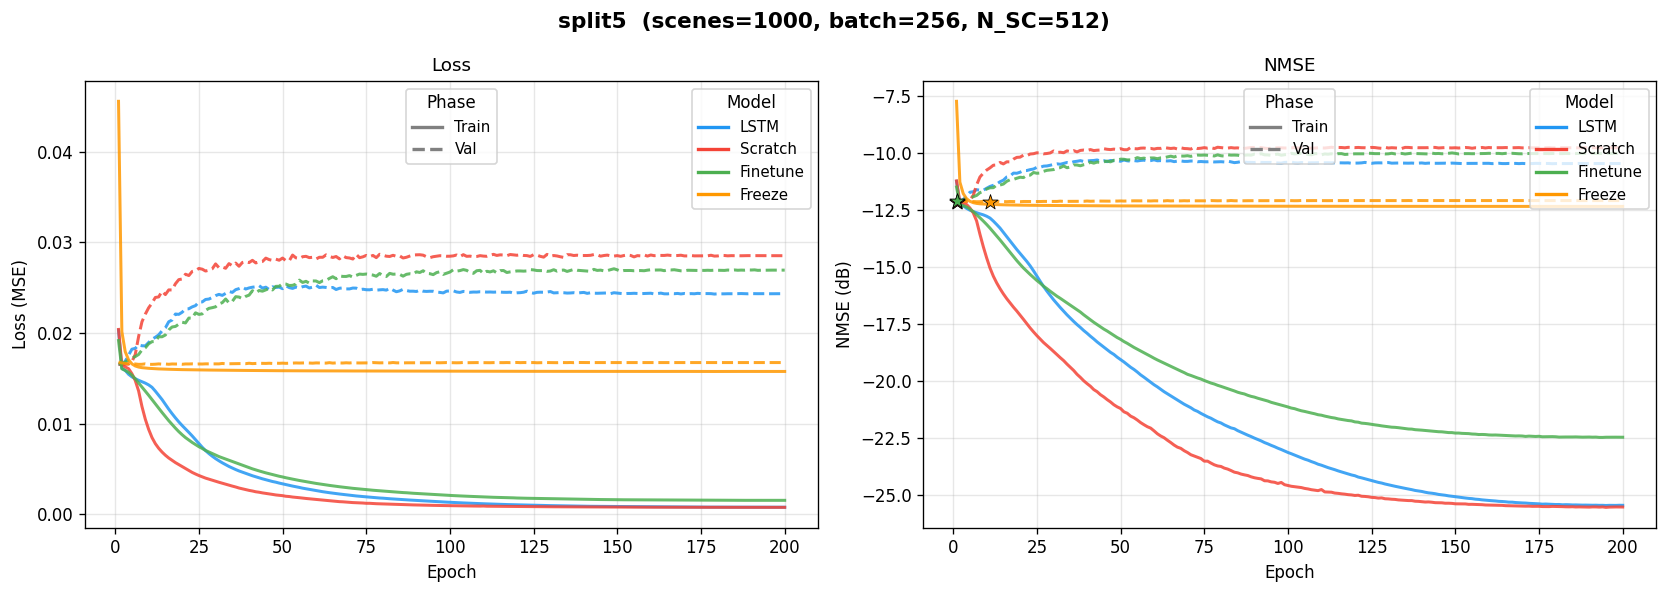

In [14]:
plot_split('split5')